In [35]:
import pandas as pd
import requests
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
import platform

In [36]:
url = "https://archive-api.open-meteo.com/v1/archive"

params =  {
    'latitude' : 37.5665, 
    'longitude' : 126.9780, 
    'start_date' : '2025-01-01', 
    'end_date' : '2025-12-31', 
    'hourly' : 'temperature_2m,relative_humidity_2m,surface_pressure,wind_speed_10m,rain'
}
res = requests.get(url, params = params)
data = res.json()
data

{'latitude': 37.57469,
 'longitude': 126.96,
 'generationtime_ms': 105.4924726486206,
 'utc_offset_seconds': 0,
 'timezone': 'GMT',
 'timezone_abbreviation': 'GMT',
 'elevation': 34.0,
 'hourly_units': {'time': 'iso8601',
  'temperature_2m': '°C',
  'relative_humidity_2m': '%',
  'surface_pressure': 'hPa',
  'wind_speed_10m': 'km/h',
  'rain': 'mm'},
 'hourly': {'time': ['2025-01-01T00:00',
   '2025-01-01T01:00',
   '2025-01-01T02:00',
   '2025-01-01T03:00',
   '2025-01-01T04:00',
   '2025-01-01T05:00',
   '2025-01-01T06:00',
   '2025-01-01T07:00',
   '2025-01-01T08:00',
   '2025-01-01T09:00',
   '2025-01-01T10:00',
   '2025-01-01T11:00',
   '2025-01-01T12:00',
   '2025-01-01T13:00',
   '2025-01-01T14:00',
   '2025-01-01T15:00',
   '2025-01-01T16:00',
   '2025-01-01T17:00',
   '2025-01-01T18:00',
   '2025-01-01T19:00',
   '2025-01-01T20:00',
   '2025-01-01T21:00',
   '2025-01-01T22:00',
   '2025-01-01T23:00',
   '2025-01-02T00:00',
   '2025-01-02T01:00',
   '2025-01-02T02:00',
   '2025

In [37]:
# 날씨 데이터들을 따로 추출 
df = pd.DataFrame(data['hourly'])
df.head(1)

,time,temperature_2m,relative_humidity_2m,surface_pressure,wind_speed_10m,rain
0,2025-01-01T00:00,0.7,65,1018.2,7.3,0.0


In [38]:
df.columns = ['측정시간', '기온', '상대습도', '지면기압', '풍속', '강수량']
df.head(10)

,측정시간,기온,상대습도,지면기압,풍속,강수량
0,2025-01-01T00:00,0.7,65,1018.2,7.3,0.0
1,2025-01-01T01:00,0.2,57,1019.4,2.0,0.0
2,2025-01-01T02:00,2.5,53,1019.5,2.1,0.0
3,2025-01-01T03:00,4.8,53,1018.8,4.6,0.0
4,2025-01-01T04:00,6.2,52,1017.9,8.3,0.0
5,2025-01-01T05:00,6.8,46,1017.0,11.9,0.0
6,2025-01-01T06:00,6.6,45,1016.8,13.9,0.0
7,2025-01-01T07:00,5.6,53,1017.0,12.3,0.0
8,2025-01-01T08:00,3.5,65,1017.2,10.3,0.0
9,2025-01-01T09:00,1.5,74,1017.7,9.0,0.0


In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   측정시간    8760 non-null   object 
 1   기온      8760 non-null   float64
 2   상대습도    8760 non-null   int64  
 3   지면기압    8760 non-null   float64
 4   풍속      8760 non-null   float64
 5   강수량     8760 non-null   float64
dtypes: float64(4), int64(1), object(1)
memory usage: 410.8+ KB


### 연습문제
1. 날씨 데이터에서 분류를 할 데이터가 존재하지 않는다.
    - 강수량 데이터를 기준으로 0 보다 큰 경우라면 1(비) 아니면 0(맑음)데이터를 이용하여 target컬럼을 생성
    - 학습 데이터 : ['기온','상대습도',' 지면기압','풍속']
2. Dataset을 만들어서 구간 3일치 데이터(72시간)로 잡는다.
3. DataLoader를 생성, batch = 64, shuffle = True
4. 측정시간 컬럼을 시계열 데이터로 변환
5. LSTM 모델을 정의
    - LSTM은 기본값들을 사용하고 batch_first = True 만 설정
6. 모델 생성, 손실 함수, 옵티마이저 구성
7. 반복 학습 (학습의 횟수는 20)
    - loss 값 반복마다 출력
    - 정확도를 출력 (후순위) : 한번의 학습마다 평균 정확도
8. 학습된 모델을 이용하여 예측


In [40]:
## 1. 강수량(rain) 기준 target 컬럼 생성
# 파생변수 target 생성 
# (df['강수량'] > 0).astype(int)
df['target'] = df['강수량'].map(
    lambda x : 1 if x > 0 else 0 
)

In [41]:
df['target'].value_counts()

target
0    7506
1    1254
Name: count, dtype: int64

In [42]:
x = df[ ['기온', '상대습도', '지면기압', '풍속'] ].values
y = df['target'].values

In [43]:
# x의 데이터에서 MinMaxScaler를 이용하여 데이터 스케일링 
x_sc = MinMaxScaler().fit_transform(x)

In [44]:
## 2. Dataset 정의 (3일치 = 72시간 구간 추출)
class windowDS(Dataset):

    def __init__(self, _x, _y, _window):
        self.x = _x
        self.y = _y
        self._window = _window
        self.n=len(x)-_window


    def __len__(self):
        return self.n


    def __getitem__(self, idx):
        x = self.x[idx : idx + self._window]
        y = self.y[idx + self._window]
        #독립변수의 데이터는 실수 형태로 전환
        x_tensor = torch.tensor(x).float()
        #종속 변수는 분류 몸델을 이용하기 때문에 정수 형태로 변환
        y_tensor = torch.tensor(y).long()
        return x_tensor, y_tensor
#72 : 72 시간을 의미 (3일)
window=72
train_ds=windowDS(x_sc,y, window)


In [45]:
## 3.  DataLoader 생성 (batch=64, shuffle=False)
#shuffle -> False : 균등하게 데이터를 확인하고 학습
train_dl = DataLoader(train_ds, batch_size=64, shuffle=False)

In [46]:
## 5. LSTM 모델 정의
# 분류형 LSTM 모델을 정의 
class LSTMclf(nn.Module):
    def __init__(
            self, 
            input_size, 
            hidden_size
    ):
        super(LSTMclf, self).__init__()
        self.lstm = nn.LSTM(
            input_size=input_size, 
            hidden_size=hidden_size, 
            batch_first=True
        )
        # 분류 모델에서는 마지막 층의 아웃풋 피쳐의 개수는 분류 개수와 동일하게 맞춰준다.
        self.model = nn.Linear(hidden_size, 2)
    
    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x)
        # h_n[-1], c_n[-1] : bidirectional이 False 인 경우에는 사용 가능 -> True인 경우에는 역방향의 아웃풋 피쳐만 불러온다. 
        # out : 3차원 데이터셋 -> [batch, window, feature]
        # 2차원 데이터셋의 형태로 변경  -> out[ :, -1, : ] -> [batch, feature]
        pred = self.model( out[:, -1, :] )
        return pred

In [47]:
## 6.  모델 생성, 손실 함수, 옵티마이저 구성
model = LSTMclf(input_size=x.shape[1], hidden_size=32)
model

LSTMclf(
  (lstm): LSTM(4, 32, batch_first=True)
  (model): Linear(in_features=32, out_features=2, bias=True)
)

In [ ]:
LSTMclf(
  (lstm): LSTM(4, 32, batch_first=True)
  (model): Linear(in_features=32, out_features=2, bias=True)
)

In [49]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr = 0.001)

In [50]:
from sklearn.metrics import accuracy_score
import numpy as np

In [51]:
## 7.  반복 학습 (loss, acc)
model.train()

for epoch in range(20):
    total_loss, total_n = 0.0, 0
    current1 = current2 = 0
    acc_list = []

    for x, y in train_dl:
        # 피쳐가 2개인 데이터 (예측값)
        res = model(x)
        loss = criterion(res, y)
        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()
        total_n += y.size(0)
        _, pred = torch.max(res, 1)
        # 분류 (예측값을 이용해 높은 부분의 인덱스를 출력)
        acc = accuracy_score(y.numpy(), pred.numpy())
        acc_list.append(acc)
        current1 += (y == pred).sum().item()
    train_loss = total_loss / len(train_dl)
    mean_currnet = (current1 / max(total_n, 1)) * 100
    current2 = np.mean(acc_list)
    print(f"Epoch : {epoch+1} , EntoryLoss : {round(total_loss, 3)}, \
          Acc1 : {round(mean_currnet, 3)}, Acc2 : {round(current2, 3)}")

Epoch : 1 , EntoryLoss : 65.567,           Acc1 : 85.566, Acc2 : 0.856
Epoch : 2 , EntoryLoss : 55.634,           Acc1 : 85.566, Acc2 : 0.856
Epoch : 3 , EntoryLoss : 55.242,           Acc1 : 85.566, Acc2 : 0.856
Epoch : 4 , EntoryLoss : 54.185,           Acc1 : 85.566, Acc2 : 0.856
Epoch : 5 , EntoryLoss : 52.129,           Acc1 : 85.566, Acc2 : 0.856
Epoch : 6 , EntoryLoss : 49.094,           Acc1 : 85.566, Acc2 : 0.856
Epoch : 7 , EntoryLoss : 46.951,           Acc1 : 85.67, Acc2 : 0.857
Epoch : 8 , EntoryLoss : 45.744,           Acc1 : 85.923, Acc2 : 0.859
Epoch : 9 , EntoryLoss : 44.68,           Acc1 : 86.107, Acc2 : 0.861
Epoch : 10 , EntoryLoss : 43.863,           Acc1 : 86.245, Acc2 : 0.863
Epoch : 11 , EntoryLoss : 43.358,           Acc1 : 86.349, Acc2 : 0.864
Epoch : 12 , EntoryLoss : 42.972,           Acc1 : 86.407, Acc2 : 0.864
Epoch : 13 , EntoryLoss : 42.608,           Acc1 : 86.384, Acc2 : 0.864
Epoch : 14 , EntoryLoss : 42.299,           Acc1 : 86.556, Acc2 : 0.866
Epo

In [52]:
## 8.  학습된 모델을 이용한 예측 (Sample 데이터)
#예측
model.eval()

eval_loader=DataLoader(train_ds, batch_size=100, shuffle=False)

#첫번쨰 데이터만 로드
x, y = next(iter(eval_loader))

with torch.no_grad():
    test_out=model(x)
    _, test_pred=torch.max(test_out, 1)

In [53]:
import matplotlib.pyplot as plt

In [54]:
if platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')
else:
    plt.rc('font', family='Malgun Gothic')

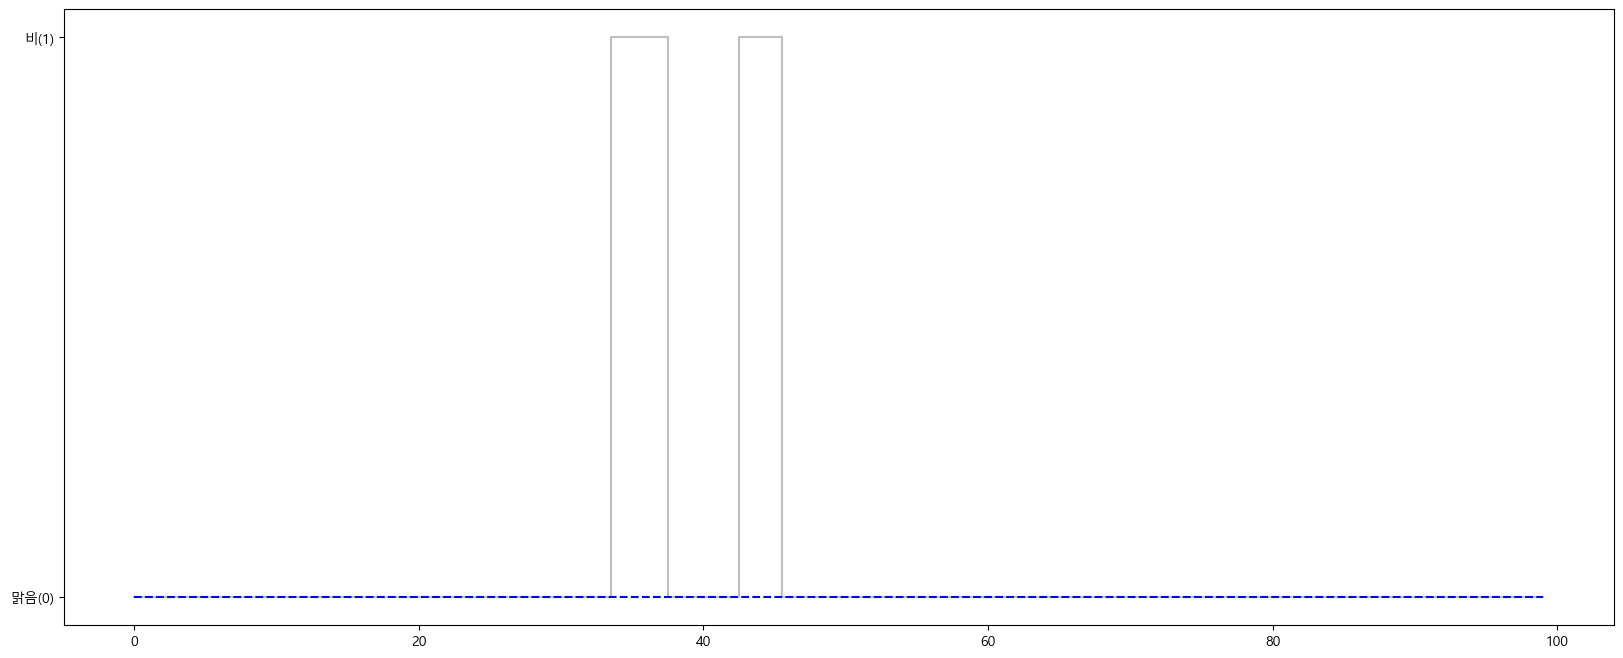

In [55]:
#그래프로 시각화
plt.figure(figsize=(20,8))

plt.plot(y.numpy(), label='실제 강수 여부', color='gray', drawstyle='steps-mid', alpha=0.5)
plt.plot(test_pred.numpy(), label='LSTM의 결과', color='blue', linestyle='--',drawstyle ='steps-mid')

plt.yticks([0,1],['맑음(0)','비(1)'])

plt.show()